In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pyproj import Proj
import math
from scipy.interpolate import interp1d
from scipy.interpolate import interp1d, PchipInterpolator, UnivariateSpline, CubicSpline
from pathlib import Path
import os
from matplotlib.ticker import MultipleLocator



def load_and_process_data(file_path, skiprows=500, flag=False, zone=52):
    window_size = 200
    if flag:
        df = pd.read_csv(
            file_path, skiprows=skiprows, skipfooter=500,
            na_values=['', 'nan', 'NaN'], engine='python'
        ).fillna(0)
    else:
        df = pd.read_csv(
        file_path, skiprows=skiprows, skipfooter=500, engine='python'
        )
        
    df.columns = [
        'Time',
        'Accelerometer x', 'Accelerometer y', 'Accelerometer z',
        'Gyroscope x', 'Gyroscope y', 'Gyroscope z',
        'Magnetometer x', 'Magnetometer y', 'Magnetometer z',
        'Orientation x', 'Orientation y', 'Orientation z',
        'Pressure', 'Latitude', 'Longitude', 'Altitude', 'Speed_GPS'
    ]

    df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S.%f')
    start_dt = df['Time'].iloc[0]
    df['Elapsed Time'] = (df['Time'] - start_dt).dt.total_seconds()
    
    df['Acc_Norm'] = np.linalg.norm(df[['Accelerometer x', 'Accelerometer y', 'Accelerometer z']].values, axis=1)
    df['Gyro_Norm'] = np.linalg.norm(df[['Gyroscope x', 'Gyroscope y', 'Gyroscope z']].values, axis=1)

    if flag:
        # (기존 원본 로직 그대로 유지)
        valid_gps_mask = (
            df['Latitude'].notna() & df['Longitude'].notna() &
            (df['Latitude'].astype(str).str.strip() != '') &
            (df['Longitude'].astype(str).str.strip() != '')
        )
        valid_lat = pd.to_numeric(df.loc[valid_gps_mask, 'Latitude'], errors='coerce')
        valid_lon = pd.to_numeric(df.loc[valid_gps_mask, 'Longitude'], errors='coerce')
        final_mask = valid_lat.notna() & valid_lon.notna()
        valid_lat = valid_lat[final_mask].values
        valid_lon = valid_lon[final_mask].values
        if len(valid_lat) == 0:
            raise ValueError("유효한 GPS 데이터가 없습니다.")
        proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
        e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
        e_valid, n_valid = proj_enu(valid_lon, valid_lat)
        e_valid -= e0; n_valid -= n0
        df['E'], df['N'] = np.nan, np.nan
        df.loc[valid_gps_mask, 'E'] = e_valid
        df.loc[valid_gps_mask, 'N'] = n_valid
        e = df['E'][df['E'].notna()].values
        n = df['N'][df['N'].notna()].values
    else:
        df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
        df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
        proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
        e_all, n_all = proj_enu(df['Longitude'].values, df['Latitude'].values)
        e0, n0 = proj_enu(df['Longitude'].iloc[0], df['Latitude'].iloc[0])
        df['E'] = e_all - e0
        df['N'] = n_all - n0
        M = len(df)
        n_sec = M // 50
        e, n = [], []
        for i in range(n_sec):
            idx = min(i*50 + 25, M-1)
            e.append(df['E'].iloc[idx])
            n.append(df['N'].iloc[idx])
        e = np.array(e)
        n = np.array(n)
            
    # -------------------------------------------------------
    # (3) Outlier 탐지
    # -------------------------------------------------------
    use_iqr=True
    dx = np.diff(e); dy = np.diff(n)
    speed = np.hypot(dx, dy)
    heading = np.arctan2(dy, dx)

    def remove_outliers_iqr(values, k=1.5):
        q1, q3 = np.percentile(values, [25, 75])
        iqr = q3 - q1
        return (values >= q1 - k*iqr) & (values <= q3 + k*iqr)

    def remove_outliers_zscore(values, threshold=3.0):
        mean, std = np.mean(values), np.std(values)
        return np.abs((values-mean)/(std+1e-8)) < threshold

    if use_iqr:
        mask_speed = remove_outliers_iqr(speed)
        mask_heading = remove_outliers_iqr(np.degrees(heading))
    else:
        mask_speed = remove_outliers_zscore(speed)
        mask_heading = remove_outliers_zscore(np.degrees(heading))

    mask = mask_speed & mask_heading
    gps_idx_all = np.arange(1, len(e))
    bad_idx = gps_idx_all[~mask]

    # -------------------------------------------------------
    # (4) 센서데이터 블록 drop (1Hz GPS → 50Hz 센서)
    # -------------------------------------------------------
    drop_idx = []
    for gi in bad_idx:
        start = gi*50
        end   = (gi+1)*50
        drop_idx.extend(range(start, min(end, len(df))))
    df = df.drop(drop_idx).reset_index(drop=True)
    
    
    if flag:
        # --- NaN 있는 경우: 유효 GPS만 모아서 다시 ENU trajectory 계산 ---
        valid_gps_mask = (
            df['Latitude'].notna() & df['Longitude'].notna() &
            (df['Latitude'].astype(str).str.strip() != '') &
            (df['Longitude'].astype(str).str.strip() != '')
        )
        valid_lat = pd.to_numeric(df.loc[valid_gps_mask, 'Latitude'], errors='coerce')
        valid_lon = pd.to_numeric(df.loc[valid_gps_mask, 'Longitude'], errors='coerce')
        final_mask = valid_lat.notna() & valid_lon.notna()
        valid_lat = valid_lat[final_mask].values
        valid_lon = valid_lon[final_mask].values
        
        if len(valid_lat) < 2:
            raise ValueError("유효 GPS가 drop 이후 2개 미만으로 남음")

        proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
        e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
        e_valid, n_valid = proj_enu(valid_lon, valid_lat)
        e, n = e_valid - e0, n_valid - n0

    else:
        # --- NaN 없는 경우: 센서 50Hz 중간 샘플 뽑기 ---
        M = len(df)
        n_sec = M // 50
        e, n = [], []
        for i in range(n_sec):
            idx = min(i*50 + 25, M-1)
            e.append(df['E'].iloc[idx])
            n.append(df['N'].iloc[idx])
        e, n = np.array(e), np.array(n)
    
    # -------------------------------------------------------
    # (5) 초기 heading 정렬 + 보간
    # -------------------------------------------------------
    dx0, dy0 = e[1]-e[0], n[1]-n[0]
    theta0 = math.atan2(dy0, dx0)
    R0 = np.array([[math.cos(-theta0), -math.sin(-theta0)],
                [math.sin(-theta0),  math.cos(-theta0)]])
    coords = np.vstack([e-e[0], n-n[0]])
    rotated = R0 @ coords
    e_corr, n_corr = rotated[0], rotated[1]

    delta_e = np.diff(e_corr)
    delta_n = np.diff(n_corr)
    
    speed_1hz = np.hypot(delta_e, delta_n)
    heading_change_1hz = np.diff(np.unwrap(np.arctan2(delta_n, delta_e)))
    n_sec_hc = []
    n_sec_speed = []
    add_num = window_size // 50
    
    for i in range(len(heading_change_1hz)):
        n_sec_speed.append(speed_1hz[i:i+add_num].sum())
        n_sec_hc.append(heading_change_1hz[i:i+add_num].sum())
       
    n_sec_speed = np.array(n_sec_speed)
    n_sec_hc = np.array(n_sec_hc)    
        
    N = len(n_sec_speed)
    N2 = len(n_sec_hc)
    
    t_old  = np.arange(N)
    t_new  = np.linspace(0, N - 1, (N - 1) * 50 + 1)

    t_old2 = np.arange(N2)   # hz1_v 길이에 맞춤
    t_new2 = np.linspace(0, N2 - 1, (N2 - 1) * 50 + 1)

    f_h_cubic = interp1d(t_old2, n_sec_hc, kind='linear', fill_value="extrapolate")
    f_v_cubic = interp1d(t_old,  n_sec_speed, kind='linear', fill_value="extrapolate")

    interp_h = f_h_cubic(t_new2)
    interp_v = f_v_cubic(t_new)
    
    plt.figure(figsize=(10, 5))
    plt.plot(np.degrees(interp_h), '.-', label='Interpolated Heading')
    plt.grid(True)
    plt.gca().yaxis.set_major_locator(MultipleLocator(90))
    plt.xlabel('Time Index')
    plt.ylabel('Heading (degrees)')
    plt.title('Interpolated Heading vs Time')
    plt.legend()
    plt.show()
    
    
    # n_sec_speed = []
    # n_sec_dh = []
    
    # for i in range(len(interp_h)):
    #     n_sec_speed.append(interp_v[i:i+add_num].sum())
    #     n_sec_dh.append(interp_h[i:i+add_num].sum()/add_num)
        
    # n_sec_speed = np.array(n_sec_speed)
    # n_sec_dh = np.array(n_sec_dh)
    
    
    e_50hz_label = []   # 동쪽 좌표 기록
    n_50hz_label = []   # 북쪽 좌표 기록

    label_heading = 0                # 초기 heading
    dt_scale = 1 / window_size       # 샘플 간 시간 비율

    for v, h in zip(interp_v, interp_h):
        # heading 업데이트 (회전각 적분)
        label_heading += h * dt_scale

        # ΔE, ΔN 계산
        de = v * dt_scale * math.cos(label_heading)
        dn = v * dt_scale * math.sin(label_heading)

        # 첫 좌표는 (0,0) 기준
        if len(e_50hz_label) == 0:
            e_50hz_label.append(de)
            n_50hz_label.append(dn)
        else:
            e_50hz_label.append(e_50hz_label[-1] + de)
            n_50hz_label.append(n_50hz_label[-1] + dn)

    # plt.figure(figsize=(10, 5))
    # plt.plot(e_corr, n_corr, 'b.-', label='GPS-ENU')
    # plt.plot(e_50hz_label, n_50hz_label, 'r.-', label='Label-ENU')
    # plt.axis('equal')
    # plt.legend()
    # plt.grid()
    # plt.show()
    
            
    num_wins = len(n_sec_speed) - window_size + 1
    
    sensor_cols = ['Accelerometer x','Accelerometer y','Accelerometer z',
                    'Gyroscope x','Gyroscope y','Gyroscope z',
                    'Acc_Norm',
                    'Gyro_Norm']
    
    sensor = df[sensor_cols].values  # shape = (T,6)

    # X = np.zeros((num_wins, window_size, len(sensor_cols)), dtype=np.float32)
    # for i in range(num_wins):
    #     X[i] = sensor[i : i+window_size]

    # Y = np.vstack([n_sec_speed, n_sec_dh]).T
    num_wins_sensor = len(sensor) - window_size + 1
    num_wins_label  = len(interp_h) - window_size + 1
    num_wins = min(num_wins_sensor, num_wins_label)

    X = np.zeros((num_wins, window_size, len(sensor_cols)), dtype=np.float32)
    for i in range(num_wins):
        X[i] = sensor[i : i+window_size]

    # Y_all = np.vstack([interp_v, interp_h]).T
    # Y = Y_all[window_size-1 : window_size-1+num_wins]
    Y = np.vstack([interp_v, interp_h]).T
    Y = Y[:num_wins]
    
    print(f"X length: {len(X)}, Y length: {len(Y)}")
            
    return df, X, Y

=== SWING 데이터 ===


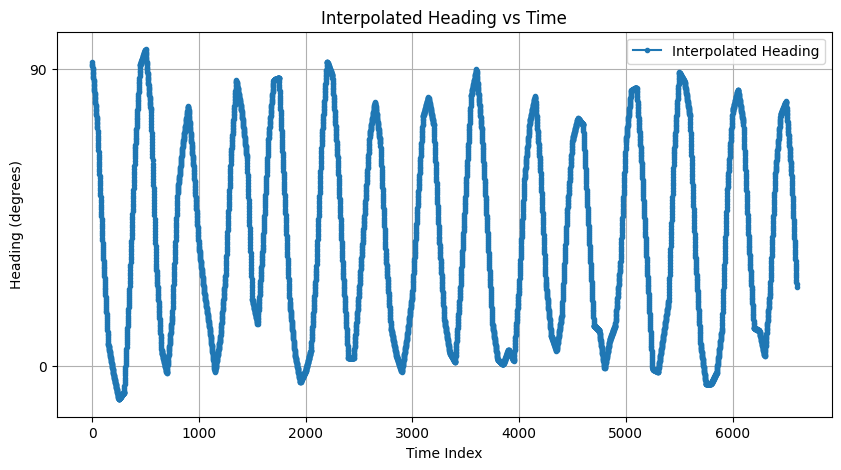

X length: 6402, Y length: 6402
[01] swing_left01.csv                 길이:   6780  ≈   2.26 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


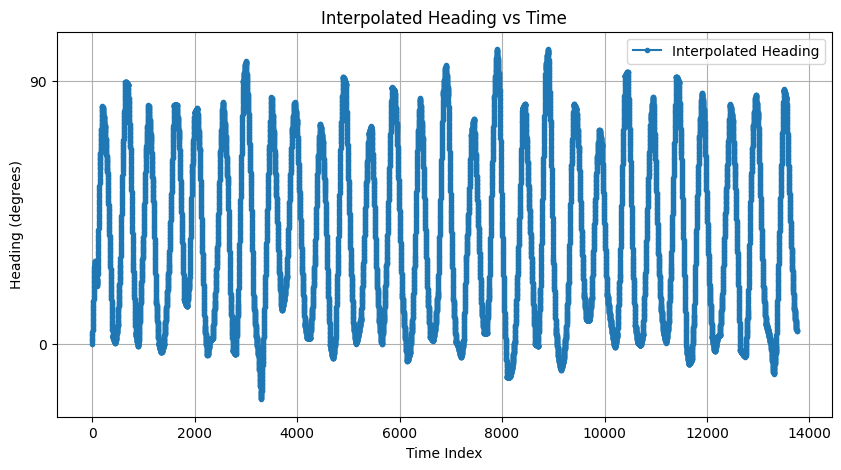

X length: 13552, Y length: 13552
[02] swing_left02.csv                 길이:  13927  ≈   4.64 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


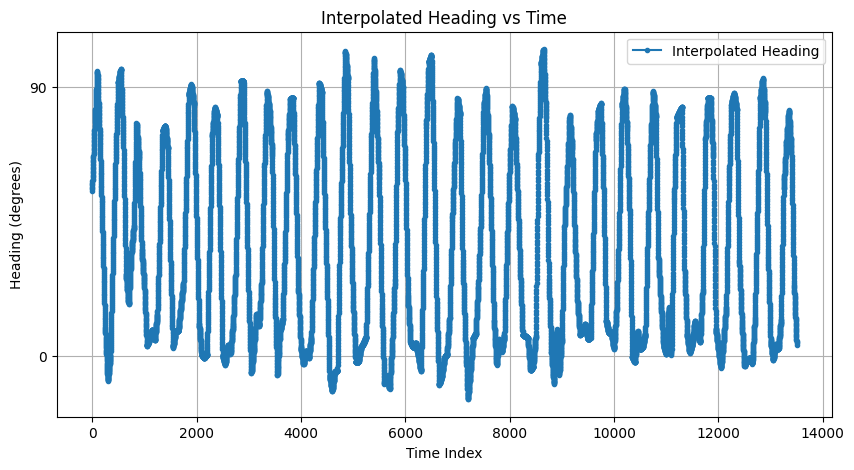

X length: 13302, Y length: 13302
[03] swing_left03.csv                 길이:  13662  ≈   4.55 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


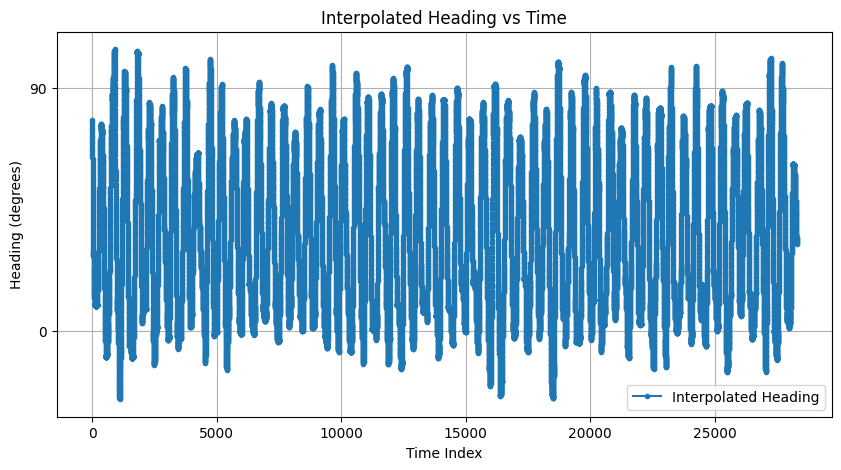

X length: 28102, Y length: 28102
[04] swing_left04.csv                 길이:  28406  ≈   9.47 분  opts={'skiprows': 1000, 'flag': True, 'zone': 52}


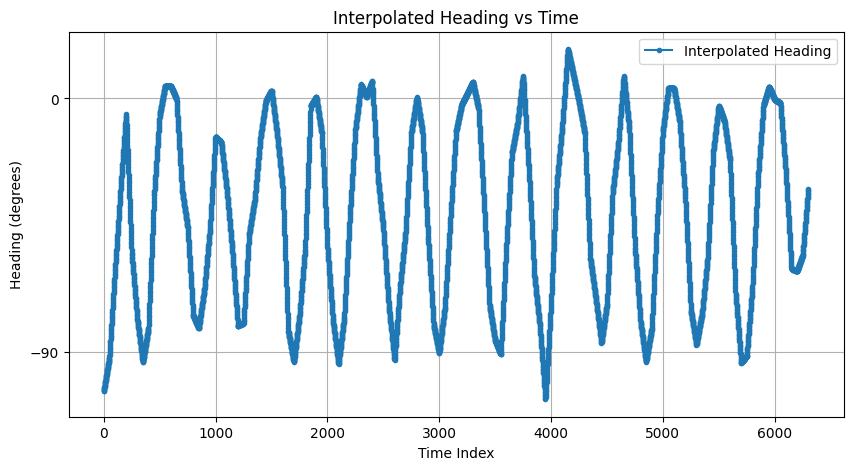

X length: 6102, Y length: 6102
[05] swing_right01.csv                길이:   6494  ≈   2.16 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


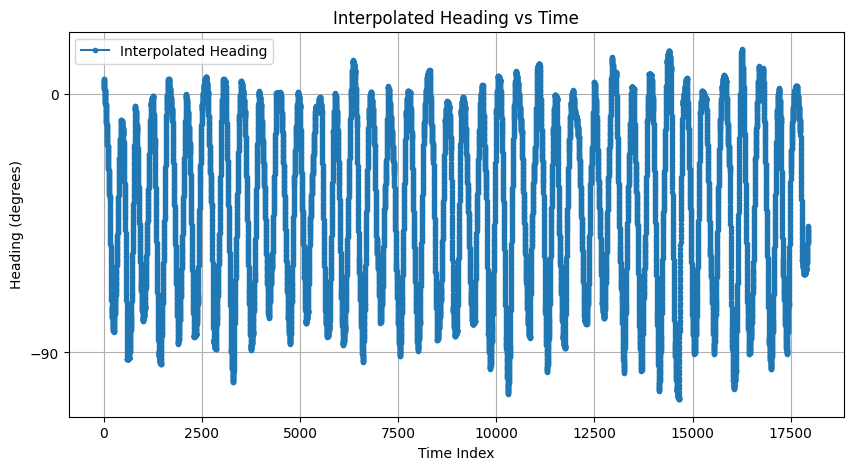

X length: 17752, Y length: 17752
[06] swing_right02.csv                길이:  18102  ≈   6.03 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


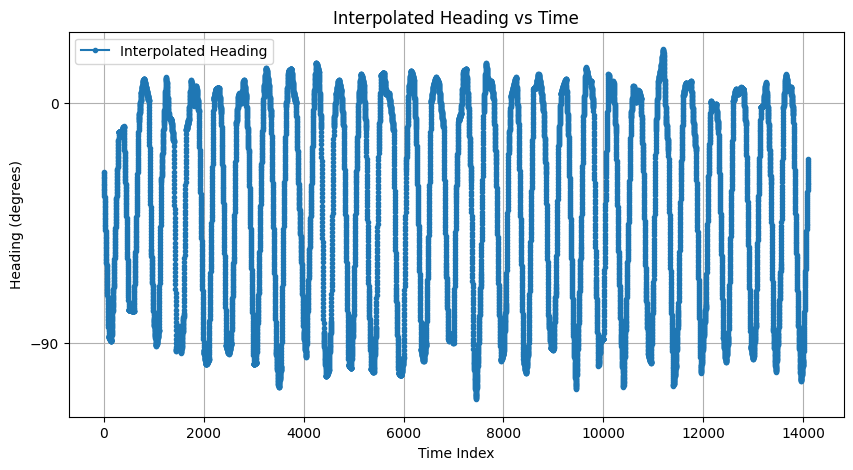

X length: 13902, Y length: 13902
[07] swing_right03.csv                길이:  14291  ≈   4.76 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


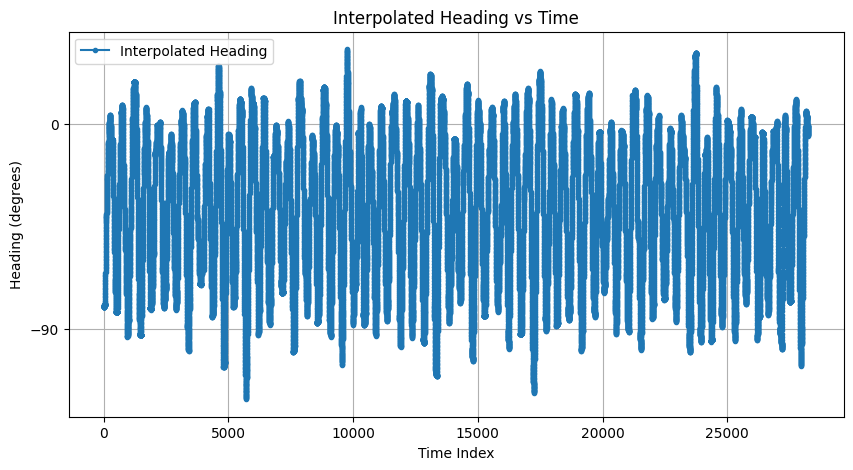

X length: 28052, Y length: 28052
[08] swing_right04.csv                길이:  28361  ≈   9.45 분  opts={'skiprows': 1000, 'flag': True, 'zone': 52}


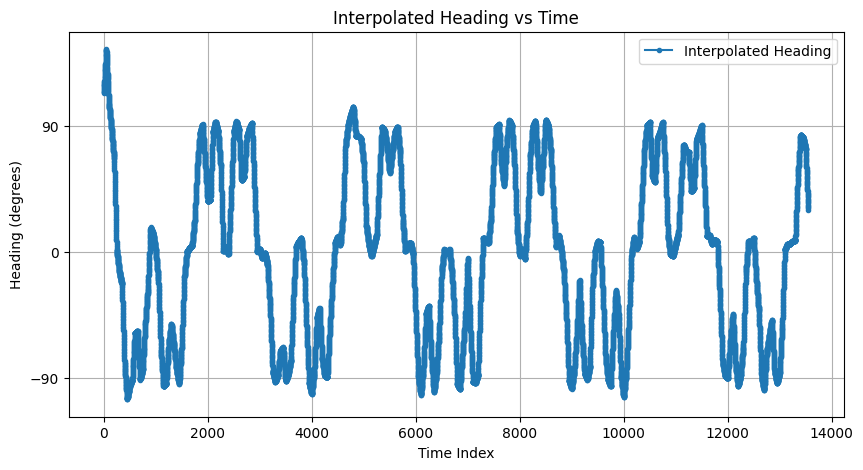

X length: 13352, Y length: 13352
[09] swing_lr01.csv                   길이:  13744  ≈   4.58 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}
--> 그룹 합계: 47.92 분

=== LOOKING 데이터 ===


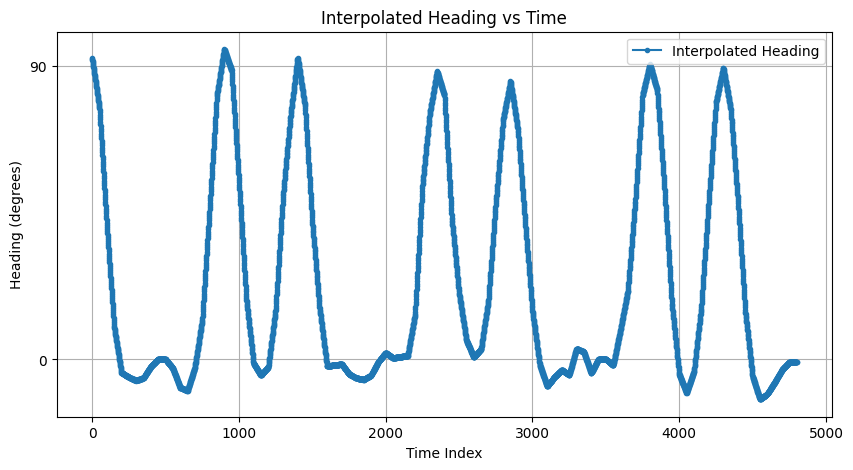

X length: 4602, Y length: 4602
[01] looking_left01.csv               길이:   4995  ≈   1.67 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


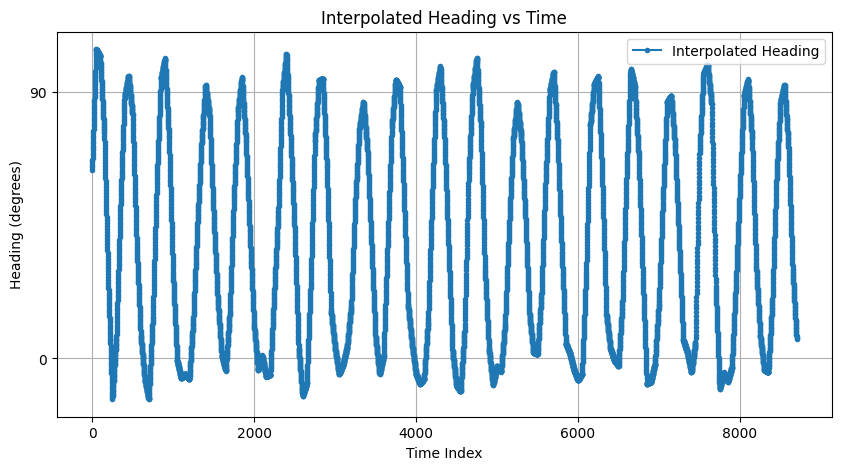

X length: 8502, Y length: 8502
[02] looking_left02.csv               길이:   8857  ≈   2.95 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


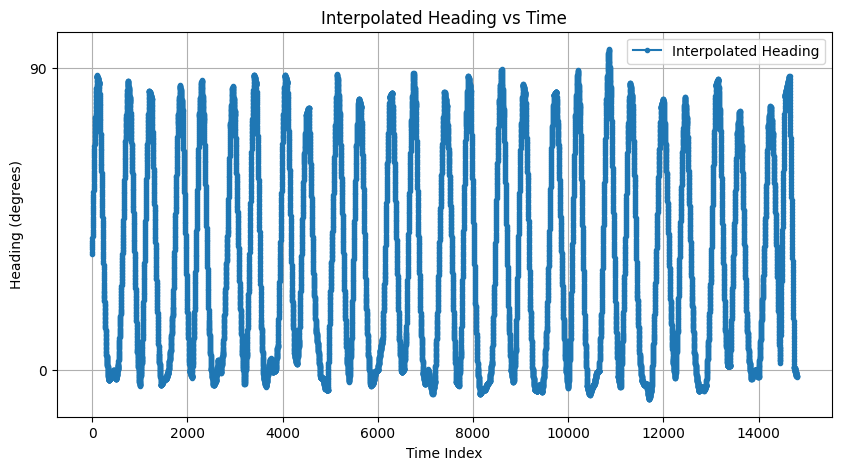

X length: 14602, Y length: 14602
[03] looking_left03.csv               길이:  14979  ≈   4.99 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


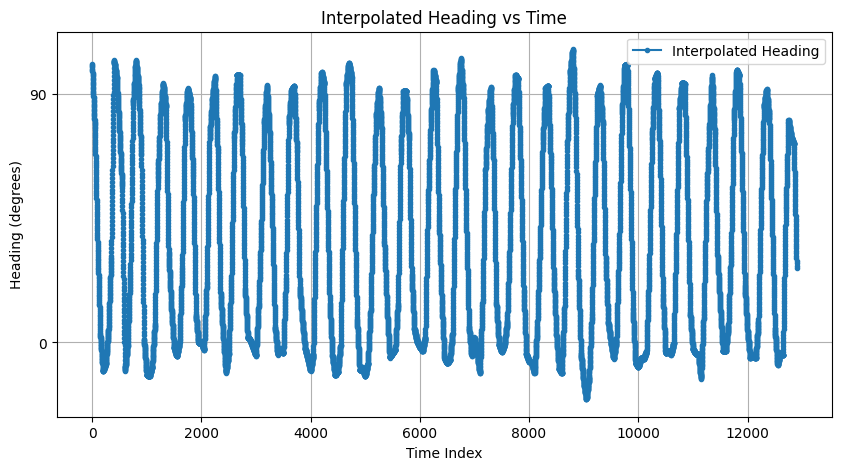

X length: 12702, Y length: 12702
[04] looking_left04.csv               길이:  13060  ≈   4.35 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


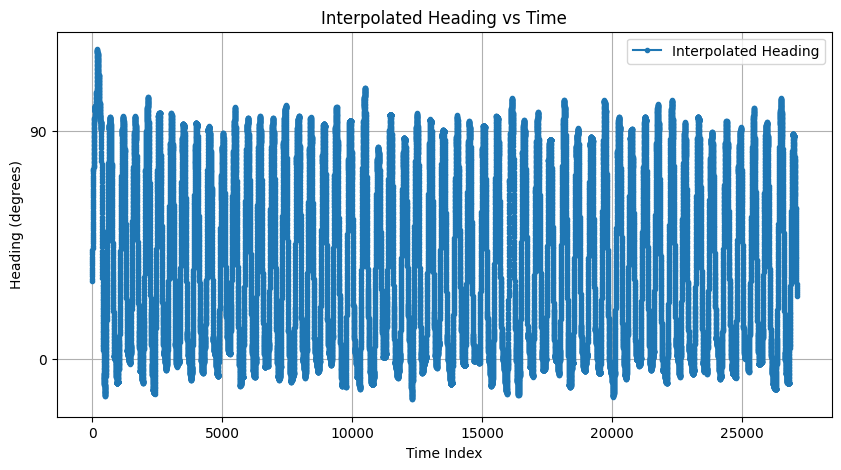

X length: 26902, Y length: 26902
[05] looking_left05.csv               길이:  27249  ≈   9.08 분  opts={'skiprows': 500, 'flag': True, 'zone': 52}


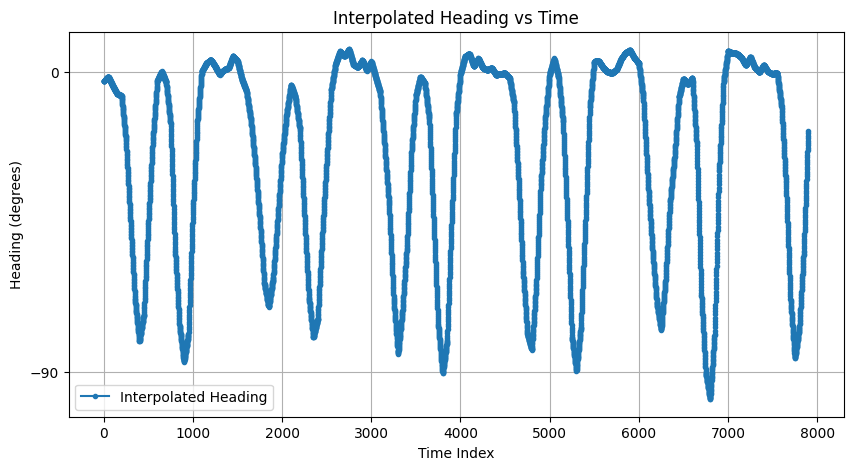

X length: 7702, Y length: 7702
[06] looking_right01.csv              길이:   8056  ≈   2.69 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


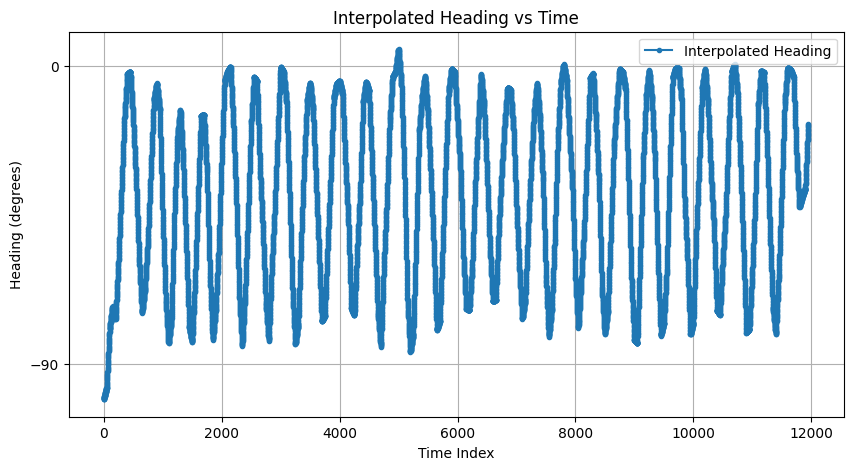

X length: 11752, Y length: 11752
[07] looking_right02.csv              길이:  12112  ≈   4.04 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


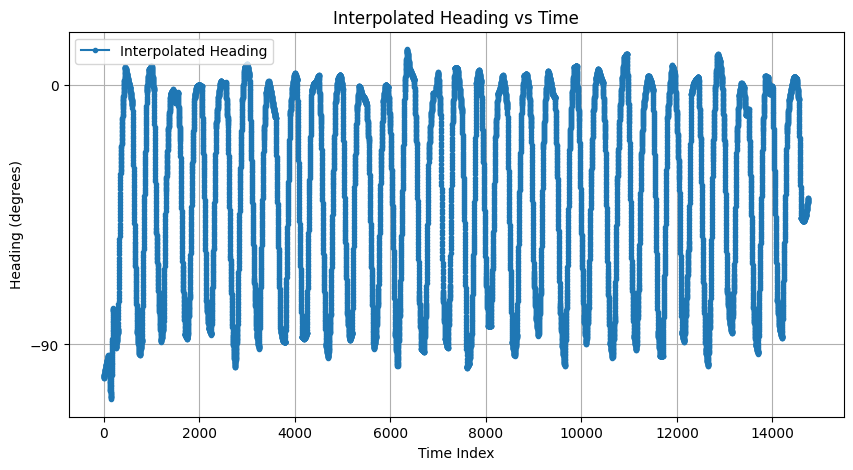

X length: 14552, Y length: 14552
[08] looking_right03.csv              길이:  14941  ≈   4.98 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


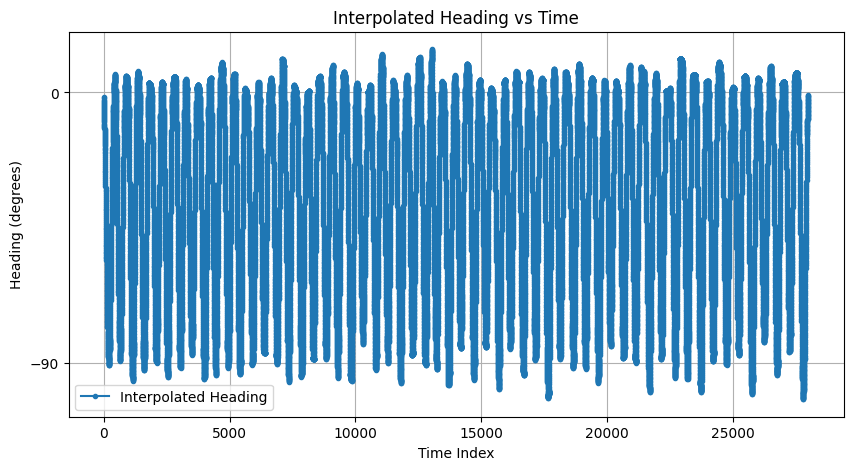

X length: 27802, Y length: 27802
[09] looking_right04.csv              길이:  28104  ≈   9.37 분  opts={'skiprows': 500, 'flag': True, 'zone': 52}


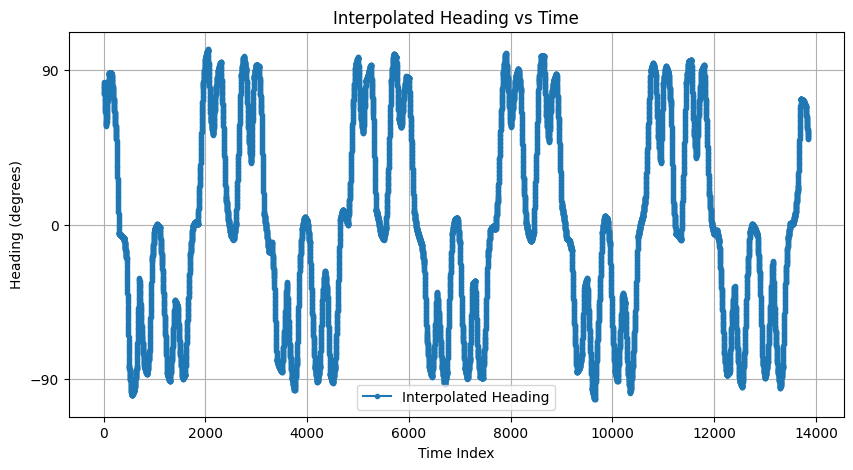

X length: 13652, Y length: 13652
[10] looking_lr01.csv                 길이:  14036  ≈   4.68 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


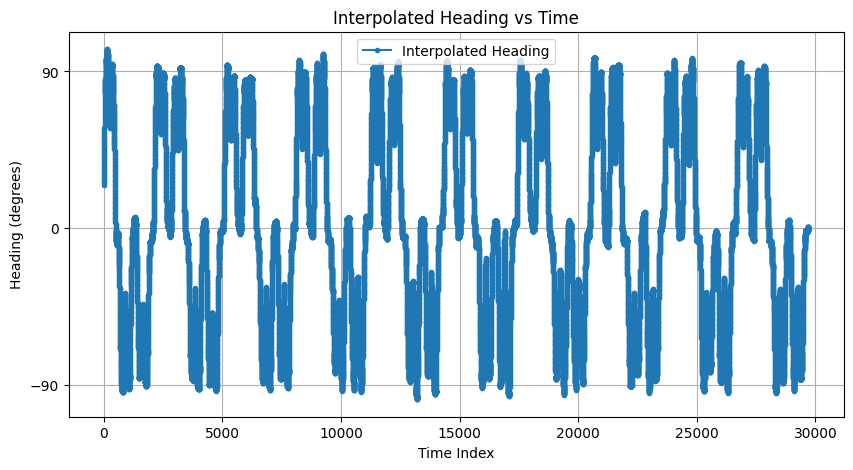

X length: 29502, Y length: 29502
[11] looking_lr02.csv                 길이:  29835  ≈   9.95 분  opts={'skiprows': 500, 'flag': True, 'zone': 52}
--> 그룹 합계: 58.74 분

요약) SWING: 47.92 분 | LOOKING: 58.74 분 | 총합: 106.66 분

=== SWING ===
file                                 min  tag         left_min  right_min
swing_left01.csv                    2.26  left            2.26       0.00
swing_left02.csv                    4.64  left            4.64       0.00
swing_left03.csv                    4.55  left            4.55       0.00
swing_left04.csv                    9.47  left            9.47       0.00
swing_right01.csv                   2.16  right           0.00       2.16
swing_right02.csv                   6.03  right           0.00       6.03
swing_right03.csv                   4.76  right           0.00       4.76
swing_right04.csv                   9.45  right           0.00       9.45
swing_lr01.csv                      4.58  lr(50/50)       2.29       2.29
-- 합계: left=23.22 min | righ

In [2]:
config = {
    'looking_left05.csv': {'skiprows': 500, 'flag': True,  'zone': 52},
    'looking_right04.csv': {'skiprows': 500, 'flag': True,  'zone': 52},
    'looking_lr02.csv':   {'skiprows': 500, 'flag': True,  'zone': 52},
    
    'swing_left04.csv' : {'skiprows': 1000, 'flag': True, 'zone': 52},  
    'swing_right04.csv' : {'skiprows': 1000, 'flag': True, 'zone': 52},
    'swing_lr02.csv' : {'skiprows': 1000, 'flag': True, 'zone': 52},

    'UTAH_looking_01.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    'UTAH_looking_02.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    'UTAH_looking_03.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    'UTAH_looking_04.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    
    
}

default_config = {'skiprows': 500, 'flag': False, 'zone': 52}

# =========================
# 전역 설정
# =========================
BASE_DIR = os.getcwd()
FS = 50  # Hz

# 학습 데이터 경로들
swing_learnData_path = [
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left04.csv'),
    
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right04.csv'),

    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_lr01.csv'),
    #os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_lr02.csv'),
]

looking_learnData_path = [
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left04.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_left05.csv'), 

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking', 'looking_right04.csv'),

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr02.csv'),

    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_01.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_02.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_03.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_04.csv'),
    

]



# =========================
# 그룹 로딩 & 길이 합산
# =========================
def load_group(paths, loader_fn, cfg=None, default_cfg=None, fs=FS):
    """
    한 그룹(paths) 로드/전처리, 파일별 옵션 자동 적용.
      - loader_fn(path, **opts) -> (df, X, Y)
      - cfg: 파일명별 옵션 dict
      - default_cfg: 기본 옵션 dict
    """
    cfg = cfg or {}
    default_cfg = default_cfg or {}
    df_list, X_list, Y_list = [], [], []
    total_min = 0.0

    for idx, p in enumerate(paths, start=1):
        fname = Path(p).name
        opts = {**default_cfg, **cfg.get(fname, {})}  # default + per-file override

        try:
            df_temp, X_temp, Y_temp = loader_fn(p, **opts)
        except Exception as e:
            print(f'[에러] {fname}: {e}')
            continue

        df_list.append(df_temp)
        X_list.append(X_temp)
        Y_list.append(Y_temp)

        minutes = len(df_temp) / fs / 60.0
        print(f'[{idx:02d}] {fname:<32} 길이:{len(df_temp):7d}  ≈ {minutes:6.2f} 분  opts={opts}')
        total_min += minutes

    print(f'--> 그룹 합계: {total_min:.2f} 분\n')
    return df_list, X_list, Y_list, total_min

# =========================
# 좌/우/혼합 분량 요약
# =========================
def summarize_turn_minutes(df_list, paths, fs=FS):
    """
    df_list: 각 파일의 DataFrame 리스트
    paths  : 각 파일의 경로 리스트 (df_list와 동일 순서)
    fs     : 샘플링 주파수(Hz)
    return : (per_file_rows, totals)
    """
    rows = []
    tot_left = 0.0
    tot_right = 0.0
    for df, p in zip(df_list, paths):
        fname = Path(p).name
        name = fname.lower()
        minutes = len(df) / fs / 60.0

        if ("lr" in name) or ("left" in name and "right" in name):
            # 혼합 데이터 → 좌/우 반반
            left_min = minutes / 2.0
            right_min = minutes / 2.0
            tag = "lr(50/50)"
        elif "left" in name:
            left_min = minutes
            right_min = 0.0
            tag = "left"
        elif "right" in name:
            left_min = 0.0
            right_min = minutes
            tag = "right"
        else:
            left_min = 0.0
            right_min = 0.0
            tag = "unknown"

        tot_left += left_min
        tot_right += right_min
        rows.append({
            'file': fname,
            'minutes': round(minutes, 2),
            'tag': tag,
            'left_min': round(left_min, 2),
            'right_min': round(right_min, 2),
        })

    totals = {
        'left': round(tot_left, 2),
        'right': round(tot_right, 2),
        'total': round(tot_left + tot_right, 2),
    }
    return rows, totals

def pretty_print_summary(title, rows, totals):
    print(f"\n=== {title} ===")
    print(f"{'file':32} {'min':>7}  {'tag':10} {'left_min':>9} {'right_min':>10}")
    for r in rows:
        print(f"{r['file']:<32} {r['minutes']:7.2f}  {r['tag']:<10} {r['left_min']:9.2f} {r['right_min']:10.2f}")
    print(f"-- 합계: left={totals['left']:.2f} min | right={totals['right']:.2f} min | total={totals['total']:.2f} min")

# (선택) 판다스 표/CSV 저장
def to_dataframe(rows):
    return pd.DataFrame(rows, columns=['file','minutes','tag','left_min','right_min'])

def save_summary_csv(prefix, rows, totals, out_dir="outputs"):
    os.makedirs(out_dir, exist_ok=True)
    df = to_dataframe(rows)
    df.to_csv(os.path.join(out_dir, f"{prefix}_per_file.csv"), index=False, encoding="utf-8-sig")
    pd.DataFrame([totals]).to_csv(os.path.join(out_dir, f"{prefix}_totals.csv"), index=False, encoding="utf-8-sig")

# =========================
# 실행부
# =========================
if __name__ == "__main__":
    loader1 = lambda path, **opts: load_and_process_data(path, **opts)

    print('=== SWING 데이터 ===')
    swing_df_list, swing_X_list, swing_Y_list, swing_min = load_group(
        swing_learnData_path, loader_fn=loader1, cfg=config, default_cfg=default_config
    )

    print('=== LOOKING 데이터 ===')
    looking_df_list, looking_X_list, looking_Y_list, looking_min = load_group(
        looking_learnData_path, loader_fn=loader1, cfg=config, default_cfg=default_config
    )

    print(f'요약) SWING: {swing_min:.2f} 분 | LOOKING: {looking_min:.2f} 분 | 총합: {swing_min + looking_min:.2f} 분')

    # 좌/우/혼합 분량 요약
    swing_rows, swing_tot = summarize_turn_minutes(swing_df_list, swing_learnData_path, fs=FS)
    pretty_print_summary("SWING", swing_rows, swing_tot)

    looking_rows, looking_tot = summarize_turn_minutes(looking_df_list, looking_learnData_path, fs=FS)
    pretty_print_summary("LOOKING", looking_rows, looking_tot)

    # 전체 합산
    all_rows = swing_rows + looking_rows
    all_tot = {
        'left':  round(swing_tot['left']  + looking_tot['left'],  2),
        'right': round(swing_tot['right'] + looking_tot['right'], 2),
        'total': round(swing_tot['total'] + looking_tot['total'], 2),
    }
    pretty_print_summary("전체(SWING + LOOKING)", all_rows, all_tot)